<a href="https://colab.research.google.com/github/bayan2002/Prediction-of-Product-Sales/blob/main/Project_1_Part_4(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project 1 - Part 4 (Core):**


In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
fpath = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/cleaned_sales_predictions_2023.csv"
df = pd.read_csv(fpath)
df.head()

,Unnamed: 0,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,MISSING,Tier 3,Grocery Store,732.3800
4,4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
# Reverting 'MISSING' in categorical columns and -1 in numeric columns to np.nan
df.replace('MISSING', np.nan, inplace=True)
df.replace(-1, np.nan, inplace=True)
df.isna().sum()


,0
Unnamed: 0,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):

  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}")

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax

# Final version of function
def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

def explore_numeric(df, x, figsize=(6,5) ):
  # Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])
  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])
  ## Adding a title
  axes[0].set_title(f"Column: {x}")
  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()
  ## Print message with info on the count and % of null values
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")

def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6,4), **kwargs): # kwargs for sns.regplot
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]
  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'edgecolor':'white', 'linewidths':1, 'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})")
  # Make sure the plot is shown before the print statement
  plt.show()
  return fig, ax

# Inspecting Each Feature

#1- Item_Weight

Feature: Item_Weight

Definition: Weight of product
  

In [ ]:
# Confirming the dtype to select correct EDA function
feature = 'Item_Weight'
df[feature].dtype

dtype('float64')

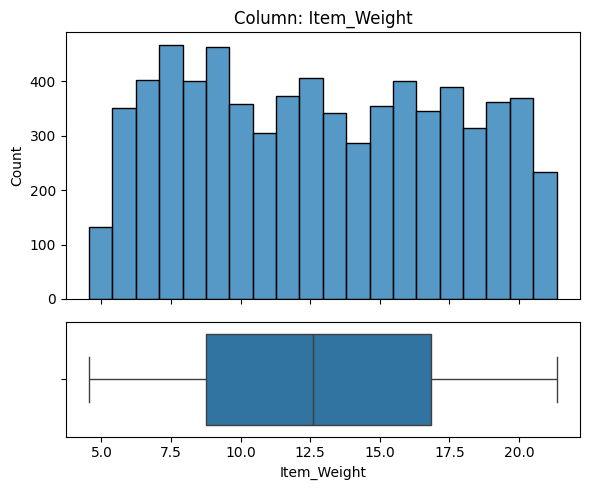

- NaN's Found: 1463 (17.17%)


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_numeric(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 1463 null values (17.17%). Since weights are missing, I would impute them with the mean or median to avoid losing data, or check if they can be filled based on the Item_Identifier

3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - Not applicable (Numeric)

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No, weight is a standard product characteristic.



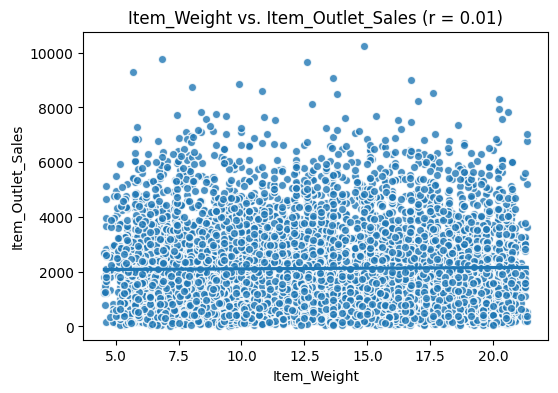

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - I do not expect weight to be a strong predictor of sales.
  - Does this feature appear to be a predictor of the target?
    -  Based on the plot, as the correlation coefficient (r) is near 0, the feature does not appear to be a strong predictor.

___

#2- Item_Fat_Content

Feature: 	Item_Fat_Content

Definition: Whether the product is low-fat or regular
  

In [ ]:
# Confirming the dtype to select correct EDA function
feature = 'Item_Fat_Content'
df[feature].dtype

dtype('O')

/tmp/ipykernel_6539/1500242967.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


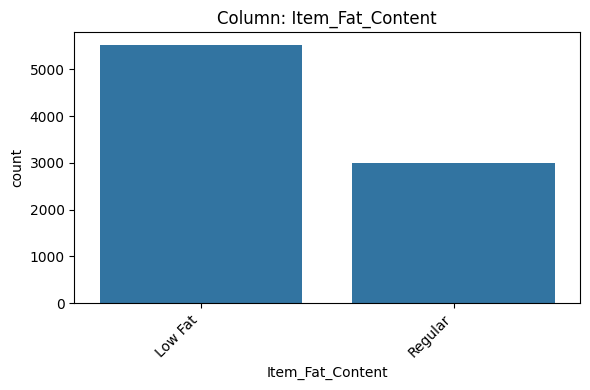

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (Nominal)
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  -  0 (0.0%). No imputation needed

3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - Low (2 unique values: 'Low Fat' and 'Regular' after cleaning inconsistencies)

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No



/tmp/ipykernel_6539/1500242967.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


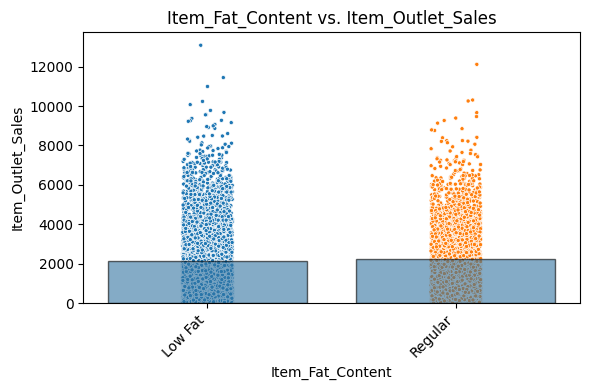

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    -  Likely yes; health-conscious consumers might prefer low-fat items, affecting sales.
  - Does this feature appear to be a predictor of the target?
    -  Based on the plot, as the correlation coefficient (r) is near 0, the feature does not appear to be a strong predictor.

___

#3- Item_Visibility

Feature: 	Item_Visibility

Definition: The percentage of total display area of all products in a store allocated to the particular product
  

In [ ]:
# Confirming the dtype to select correct EDA function
feature = 'Item_Visibility'
df[feature].dtype

dtype('float64')

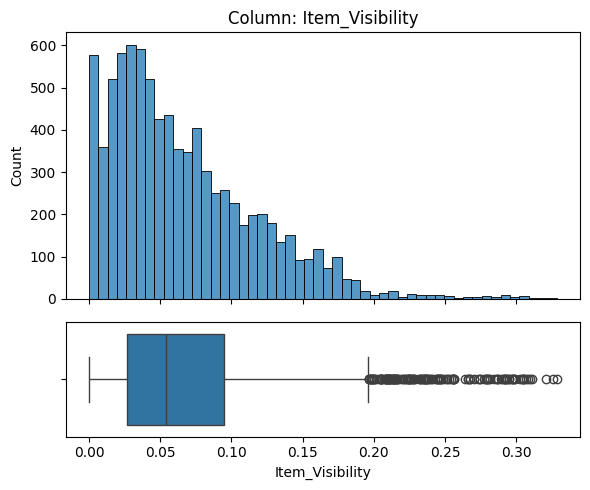

- NaN's Found: 0 (0.0%)


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_numeric(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  -  0 (0.0%). However, there are many "0.0" values which may be "hidden" missing data since a product must have some visibility to be sold

3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - N/A (Numeric)

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No



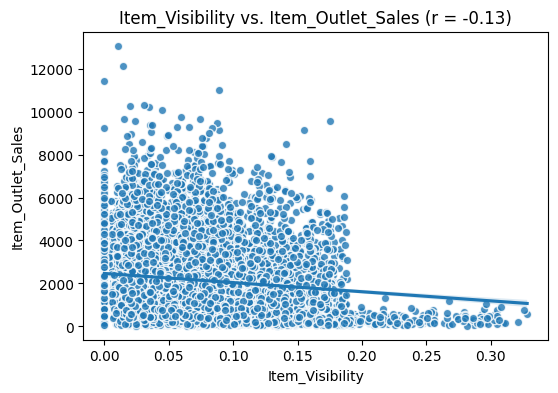

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    -  Yes, higher visibility usually leads to higher sales.
  - Does this feature appear to be a predictor of the target?
    -  Interestingly, this feature shows a slight negative correlation (r<0), suggesting that high-visibility spots might be used for slower-moving items

___

#4- Item_Type

Feature: 	Item_Type

Definition: The category to which the product belongs
  

In [ ]:
# Confirming the dtype to select correct EDA function
feature = 'Item_Type'
df[feature].dtype

dtype('O')

/tmp/ipykernel_6539/1500242967.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


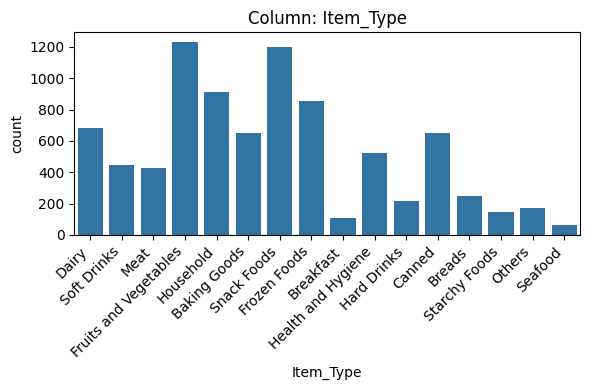

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (Nominal)
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  -  0 (0.0%).

3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - High (16 unique categories). This is above 10 and may be problematic for some models

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No



/tmp/ipykernel_6539/1500242967.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


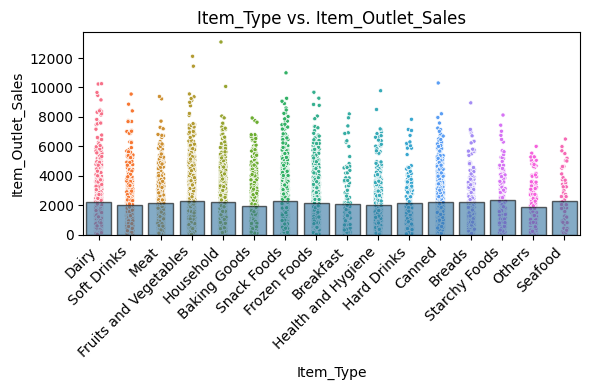

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, certain categories (like "Fruits and Vegetables" or "Snack Foods") likely sell more than others (like "Seafood")
  - Does this feature appear to be a predictor of the target?
    -  Yes, significant variability in mean sales is visible across categories

___

#5- Item_MRP

Feature: 	Item_MRP

Definition: Maximum Retail Price (list price) of the product
  

In [ ]:
# Confirming the dtype to select correct EDA function
feature = 'Item_MRP'
df[feature].dtype

dtype('float64')

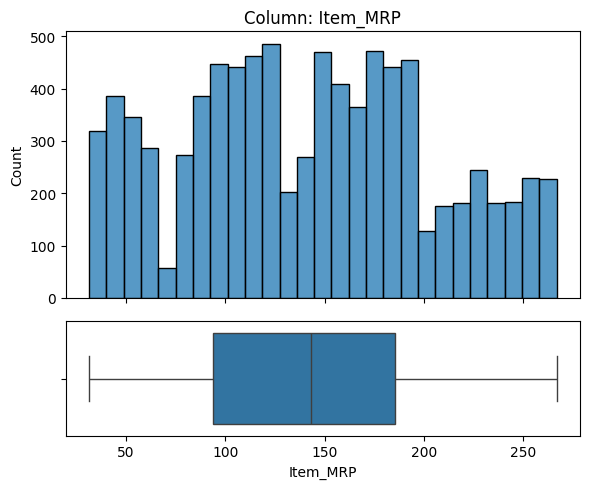

- NaN's Found: 0 (0.0%)


In [ ]:
# run the appropriate explore function (based on feature's dtype)
explore_numeric(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  -  0 (0.0%).
3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - N/A (Numeric)

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No



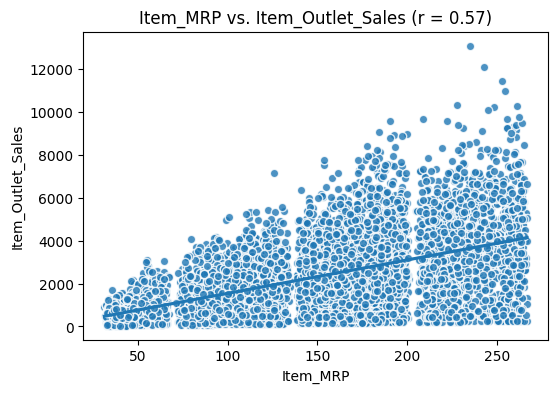

In [ ]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    -  Yes, price is usually the most direct driver of total sales revenue.
  - Does this feature appear to be a predictor of the target?
    -  Strong Predictor. The plot shows a clear positive trend with a moderate to high correlation (r≈0.57)

___




#6- Outlet_Identifier

Feature: 	Outlet_Identifier

Definition: Unique store ID
  

In [31]:
# Confirming the dtype to select correct EDA function
feature = 'Outlet_Identifier'
df[feature].dtype

dtype('O')

/tmp/ipykernel_6539/1500242967.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


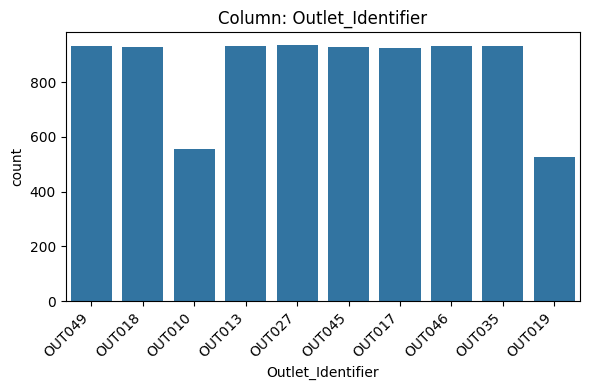

- NaN's Found: 0 (0.0%)
- Unique Values: 10
- Most common value: 'OUT027' occurs 935 times (10.97%)
- Not constant or quasi-constant.


In [32]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (nominal)
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  -  0 (0.0%).

3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - 10 unique IDs. This is right at the threshold of "high cardinality" (~10) but is manageable for most models

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No, as specific outlets may have unique management or local factors driving sales.



/tmp/ipykernel_6539/1500242967.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


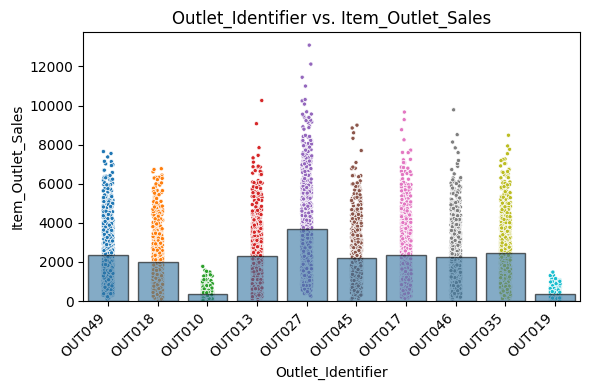

In [33]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    -  Yes, different stores likely have different performance levels.
  - Does this feature appear to be a predictor of the target?
    -  yes, there is significant variability; for example, OUT027 often shows much higher mean sales than others

___

# 7- Outlet_Establishment_Year

Feature: 	Outlet_Establishment_Year

Definition: The year in which store was established
  

In [34]:
# Confirming the dtype to select correct EDA function
feature = 'Outlet_Establishment_Year'
df[feature].dtype

dtype('int64')

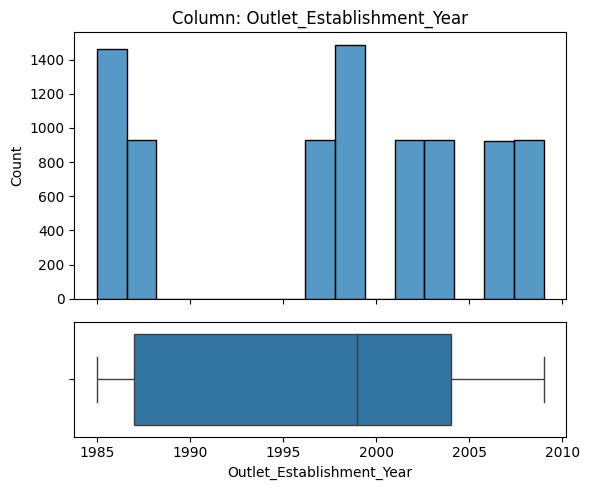

- NaN's Found: 0 (0.0%)


In [35]:
# run the appropriate explore function (based on feature's dtype)
explore_numeric(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Numeric (can be treated as Ordinal)
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  -  0 (0.0%).

3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - N/A (9 unique years).

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No, older stores might have a more loyal customer base.



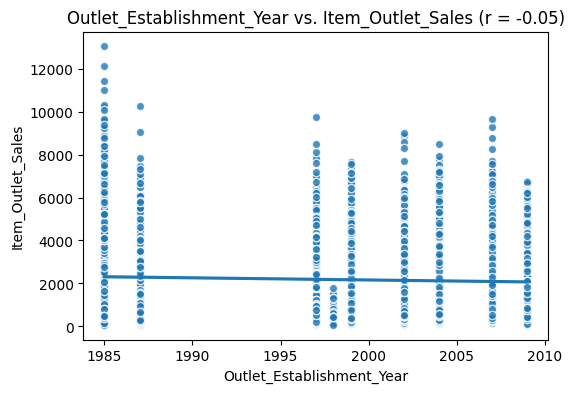

In [36]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    -  Yes, store age often impacts brand trust and sales.
  - Does this feature appear to be a predictor of the target?
    -  Based on the plot, correlation (r) is typically very low, suggesting year alone isn't a strong linear predictor
___

#8- Outlet_Size

Feature: Outlet_Size

Definition: The size of the store in terms of ground area covered
  

In [37]:
# Confirming the dtype to select correct EDA function
feature = 'Outlet_Size'
df[feature].dtype

dtype('O')

/tmp/ipykernel_6539/1500242967.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


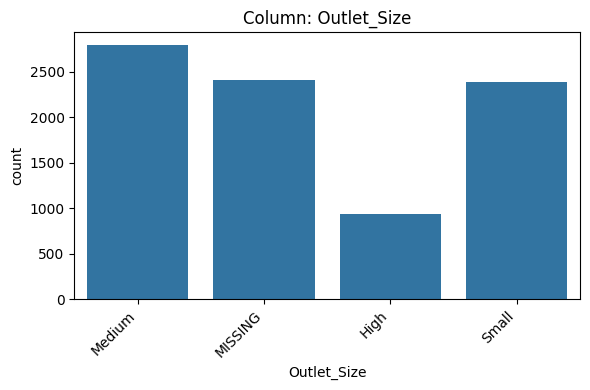

- NaN's Found: 2410 (28.28%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


In [38]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  -  Categorical (Ordinal: Small, Medium, High).
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  -  2410 (28.28%). Impute with placholder MISSING

3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - Low (3 categories + MISSING)

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No



/tmp/ipykernel_6539/1500242967.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


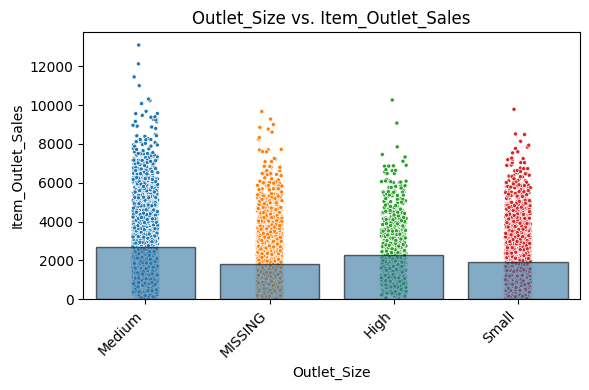

In [39]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    -  Yes, larger stores usually move more volume.
  - Does this feature appear to be a predictor of the target?
    -  Yes, "Medium" sized stores frequently show the highest average sales

___

#9- Outlet_Location_Type

Feature: Outlet_Location_Type

Definition: The type of area in which the store is located
  

In [27]:
# Confirming the dtype to select correct EDA function
feature = 'Outlet_Location_Type'
df[feature].dtype

dtype('O')

/tmp/ipykernel_6539/1500242967.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


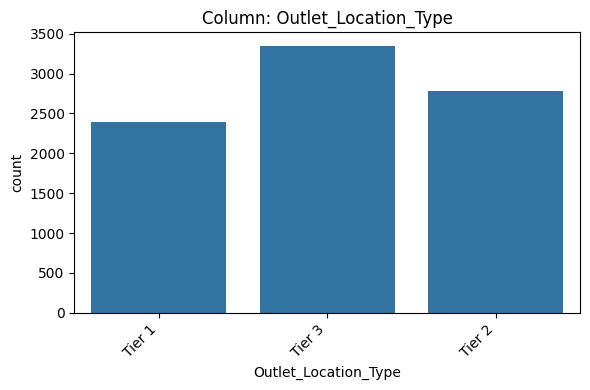

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


In [28]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (Ordinal: Tier 1, Tier 2, Tier 3)
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  -  0 (0.0%).

3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - low (3 categories)

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No



/tmp/ipykernel_6539/1500242967.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


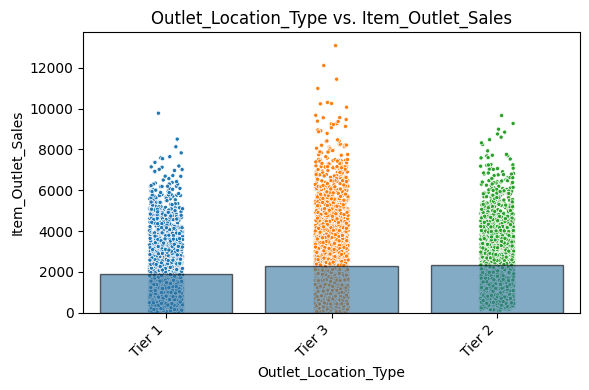

In [29]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    -  Yes, Tier 3 (larger/more developed cities) should theoretically have higher sales.
  - Does this feature appear to be a predictor of the target?
    -  Yes, variability is visible, with Tier 3 often showing a higher range of sales

___

#10- Outlet_Type

Feature: Outlet_Type

Definition: Whether the outlet is a grocery store or some sort of supermarket
  

In [22]:
# Confirming the dtype to select correct EDA function
feature = 'Outlet_Type'
df[feature].dtype

dtype('O')

/tmp/ipykernel_6539/1500242967.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


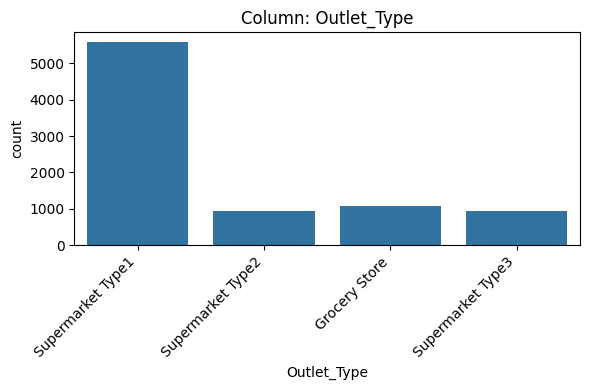

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [23]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(df=df, x= feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (nominal)
2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  -  0 (0.0%).

3. Is the feature constant or quasi-constant?
  - No

4. What is the cardinality? Is it high?
  - Low (4 categories)

5. Would we know this BEFORE the target is determined?
  - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
  - No



/tmp/ipykernel_6539/1500242967.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


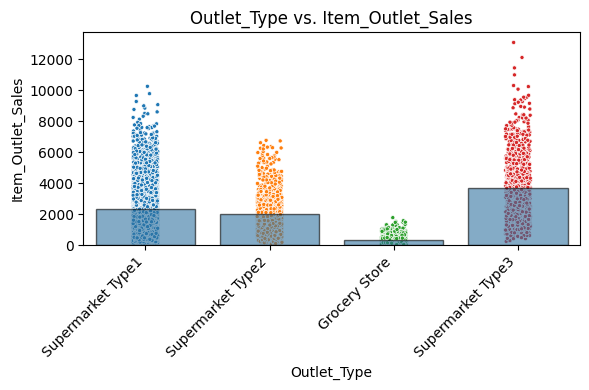

In [25]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(df=df, x=feature);

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    -  Yes, supermarkets should have significantly higher sales than grocery stores
  - Does this feature appear to be a predictor of the target?
    - Supermarket Type 3 typically shows much higher sales than Grocery Stores